# Run B-RN — ZipDepth backbone with a randomly initialised neck and head

Follow-up of Run B (ZipDepth-base encoder replacing the YOLO26n backbone). Run B used 1×1 Conv-BN-SiLU adapters and a
COCO-initialised neck and head. This run changes one thing: the YOLO26n neck and detection head start from **random weights** instead of COCO; everything else is identical to Run B
(depth-pretrained encoder, locked `exp_config.yaml`, same seed). The comparison with Run B isolates whether the COCO-trained neck/head, which was trained on YOLO backbone features, helps or hinders the ZipDepth backbone.

| Run | Encoder | Adapters | Neck + head |
|---|---|---|---|
| A | YOLO26n backbone (COCO) | — | COCO |
| B | ZipDepth (depth-pretrained) | 1 layer (1×1) | COCO |
| **B-RN** | ZipDepth (depth-pretrained) | **1 layer** | **random** |

```mermaid
flowchart LR
    I[image 0-1] --> N[ImageNet norm] --> Z[ZipDepth encoder<br/>pretrained]
    Z -->|s2 96ch /8| A1[1×1 adapter → 128] -->|P3| NK[YOLO26n neck<br/>random init]
    Z -->|s3' 192ch /16| A2[1×1 adapter → 128] -->|P4| NK
    Z -->|s4' 384ch /32| A3[1×1 adapter → 256] -->|P5| NK
    NK --> H[Detect head<br/>random init]
```

**Flow:** build the model → sanity checks → overfit/checkpoint/resume test on 32 images → *all checks must pass* →
full training (skipped if a finished run exists, resumed if interrupted) → evaluation of A, B and B-RN with identical code
in the same session → comparison table.

**Requires on Drive** (`MyDrive/lab/`): `exp_config.yaml`, `runs/A_yolo26n/` (Run A notebook) and
`runs/B_zipdepth/` (Run B notebook). **Writes:** `zipdepth_yolo.py` (backward compatible with Run B checkpoints),
`runs/B_zipdepth_rn/`, `results/results_B_zipdepth_rn.json`, `results/comparison_B_zipdepth_rn.csv`.

## 1. Setup

In [ ]:
import sys, subprocess
if "google.colab" in sys.modules:
    subprocess.run([sys.executable, "-m", "pip", "-q", "install", "ultralytics>=8.4"], check=True)

In [ ]:
import os, json, time, copy, random, shutil, importlib
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt, torch, yaml
from PIL import Image

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    ROOT, DATA_ROOT, WORK = Path("/content/drive/MyDrive/lab"), Path("/content/datasets"), Path("/content")
else:
    ROOT, DATA_ROOT, WORK = Path("lab_drive").resolve(), Path("datasets").resolve(), Path(".").resolve()
os.chdir(WORK)

# ZipDepth repo: clone only (its requirements.txt would reinstall torch)
ZD_DIR = WORK / "ZipDepth"
if not ZD_DIR.exists():
    subprocess.run(["git", "clone", "-q", "https://github.com/fabiotosi92/ZipDepth.git", str(ZD_DIR)], check=True)
ZD_CKPT = ZD_DIR / "checkpoints/zipdepth_base.pth"
for p in (str(ZD_DIR), str(WORK)):
    if p not in sys.path:
        sys.path.insert(0, p)

import ultralytics
from ultralytics import YOLO

# Variant of this notebook (only these lines differ between the follow-up notebooks)
NEW = "B-RN"                                    # label used in tables and plots
ADAPTER_LAYERS = 1                             # 1 = Run B, 3 = 1x1 -> 3x3 -> 1x1
COCO_NECK_HEAD = False                         # False = neck and head start from random weights
SCHEDULE = {}                                  # {} = locked 50-epoch schedule (comparable with A and B);
                                               # e.g. {"epochs": 150, "patience": 20} for a long run with early stopping

DEVICE = "cuda:0" if torch.cuda.is_available() else "cpu"
GPU_NAME = torch.cuda.get_device_name(0) if DEVICE != "cpu" else "CPU"
SMOKE = DEVICE == "cpu"                        # CPU: pipeline check only
sfx = ("_long" if SCHEDULE else "") + ("_smoke" if SMOKE else "")
RUN_A, RUN_B = ("A_yolo26n_smoke", "B_zipdepth_smoke") if SMOKE else ("A_yolo26n", "B_zipdepth")
RUN_N = "B_zipdepth_rn" + sfx
KEYS = ["A", "B", NEW]
pd.set_option("display.precision", 3)
print(f"torch {torch.__version__} | ultralytics {ultralytics.__version__} | {GPU_NAME} | SMOKE={SMOKE} | "
      f"runs {RUN_A}, {RUN_B} vs {RUN_N}")

Mounted at /content/drive
Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
torch 2.11.0+cu130 | ultralytics 8.4.171 | Tesla T4 | SMOKE=False | runs A_yolo26n, B_zipdepth vs B_zipdepth_rn


## 2. Data and configuration

Same data, label table (`cache/kitti_labels.csv`) and locked configuration as Runs A and B, read from Drive.
`SCHEDULE` (setup cell) can override the number of epochs and the early-stopping patience; the default keeps the
50-epoch schedule of A and B so that the three runs differ only in the model.

In [ ]:
%%writefile lab_eval.py
"""lab_eval.py - shared evaluation utilities for runs A / B / C (YOLO26n vs ZipDepth backbone on KITTI).

Every run is evaluated with this file, unchanged, so that all numbers in the comparison table
come from identical code.
"""
import json
import time
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from PIL import Image
from ultralytics.utils.metrics import ap_per_class, box_iou

# 10 IoU thresholds of mAP50-95, built exactly like Ultralytics (float32) so that ">= threshold" matches bit for bit.
IOUV = torch.linspace(0.5, 0.95, 10).numpy()

# Size buckets by ground-truth box height in original image pixels (25 px = KITTI minimum height for Moderate/Hard).
SIZE_BUCKETS = {"small (<25px)": (0.0, 25.0), "medium (25-50px)": (25.0, 50.0), "large (>=50px)": (50.0, float("inf"))}


# ----------------------------------------------------------------------------- labels
def bucket_of(h):
    for name, (lo, hi) in SIZE_BUCKETS.items():
        if lo <= h < hi:
            return name
    return list(SIZE_BUCKETS)[0]


def build_label_df(kitti_dir, names, splits=("train", "val")):
    """One row per ground-truth object: split, image, image size, class, normalised and pixel box, height, bucket."""
    rows = []
    for split in splits:
        for img in sorted((Path(kitti_dir) / "images" / split).glob("*.png")):
            W, H = Image.open(img).size
            lbl = Path(kitti_dir) / "labels" / split / (img.stem + ".txt")
            if not lbl.exists() or lbl.stat().st_size == 0:
                continue
            for c, xc, yc, w, h in np.loadtxt(lbl, ndmin=2):
                rows.append((split, img.name, str(img), W, H, int(c), xc, yc, w, h))
    df = pd.DataFrame(rows, columns=["split", "image", "path", "img_w", "img_h", "cls", "xc", "yc", "w", "h"])
    df["name"] = df["cls"].map(names)
    df["x1"] = (df.xc - df.w / 2) * df.img_w
    df["y1"] = (df.yc - df.h / 2) * df.img_h
    df["x2"] = (df.xc + df.w / 2) * df.img_w
    df["y2"] = (df.yc + df.h / 2) * df.img_h
    df["h_px"] = df.y2 - df.y1
    df["bucket"] = df.h_px.map(bucket_of)
    return df


def load_label_df(kitti_dir, names, cache_path):
    """Build the label table once and cache it as CSV (e.g. on Drive)."""
    cache_path = Path(cache_path)
    if cache_path.exists():
        return pd.read_csv(cache_path)
    df = build_label_df(kitti_dir, names)
    cache_path.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(cache_path, index=False)
    return df


# ----------------------------------------------------------------------------- matching
def match_with_index(pred_cls, gt_cls, iou):
    """Greedy matching identical to Ultralytics DetectionValidator.match_predictions(use_scipy=False),
    but returning the matched gt index. iou: (L gt, D det). Returns (D, 10) int array, -1 = unmatched."""
    D, L = len(pred_cls), len(gt_cls)
    out = -np.ones((D, len(IOUV)), int)
    if D == 0 or L == 0:
        return out
    iou = iou * (gt_cls[:, None] == pred_cls[None, :])
    for i, t in enumerate(IOUV):
        m = np.array(np.nonzero(iou >= t)).T
        if m.shape[0]:
            if m.shape[0] > 1:
                m = m[iou[m[:, 0], m[:, 1]].argsort()[::-1]]
                m = m[np.unique(m[:, 1], return_index=True)[1]]
                m = m[np.unique(m[:, 0], return_index=True)[1]]
            out[m[:, 1], i] = m[:, 0]
    return out


def make_record(pred_boxes, pred_cls, pred_conf, gt_cls, gt_boxes):
    L, D = len(gt_boxes), len(pred_boxes)
    iou = (box_iou(torch.as_tensor(gt_boxes, dtype=torch.float32), torch.as_tensor(pred_boxes, dtype=torch.float32)).numpy()
           if L and D else np.zeros((L, D), np.float32))
    pred_cls, gt_cls = np.asarray(pred_cls, int), np.asarray(gt_cls, int)
    return dict(conf=np.asarray(pred_conf, np.float32), pcls=pred_cls,
                ph=(pred_boxes[:, 3] - pred_boxes[:, 1]) if D else np.zeros(0),
                match=match_with_index(pred_cls, gt_cls, iou),
                gcls=gt_cls, gh=(gt_boxes[:, 3] - gt_boxes[:, 1]) if L else np.zeros(0))


@torch.no_grad()
def collect_predictions(model, gt_df, imgsz=640, device=None, conf=0.001, iou=0.7, max_det=300):
    """Batch-1 prediction on every image in gt_df (same thresholds as model.val()), one record per image."""
    recs = []
    for path, g in gt_df.groupby("path", sort=True):
        r = model.predict(path, imgsz=imgsz, conf=conf, iou=iou, max_det=max_det, device=device, verbose=False)[0]
        b = r.boxes
        recs.append(make_record(b.xyxy.cpu().numpy(), b.cls.cpu().numpy().astype(int), b.conf.cpu().numpy(),
                                g.cls.values, g[["x1", "y1", "x2", "y2"]].values.astype(np.float32)))
    return recs


# ----------------------------------------------------------------------------- AP per size bucket
def _in(h, lo, hi):
    return ((h >= lo) | (lo <= 0)) & (h < hi)


def bucket_ap(recs, nc, lo=0.0, hi=float("inf")):
    """COCO-style AP restricted to gt boxes with height in [lo, hi).
    TP: matched a gt in the bucket. Ignored: matched a gt outside the bucket, or unmatched with its own height outside.
    FP: unmatched and inside the bucket. With (0, inf) this equals Ultralytics' mAP computation exactly.
    Returns ap (nc, 10) with NaN for classes without gt in the bucket, and n_gt (nc,)."""
    ap = np.full((nc, len(IOUV)), np.nan)
    n_gt = np.zeros(nc, int)
    for r in recs:
        n_gt += np.bincount(r["gcls"][_in(r["gh"], lo, hi)], minlength=nc)[:nc]
    for t in range(len(IOUV)):
        confs, pcls, tps, tcls = [], [], [], []
        for r in recs:
            m, in_gt, in_pred = r["match"][:, t], _in(r["gh"], lo, hi), _in(r["ph"], lo, hi)
            matched = m >= 0
            tp = np.zeros(len(m), bool)
            tp[matched] = in_gt[m[matched]]
            keep = ~((matched & ~tp) | (~matched & ~in_pred))
            confs.append(r["conf"][keep]); pcls.append(r["pcls"][keep]); tps.append(tp[keep]); tcls.append(r["gcls"][in_gt])
        tcls = np.concatenate(tcls)
        if len(tcls):
            res = ap_per_class(np.concatenate(tps)[:, None], np.concatenate(confs), np.concatenate(pcls), tcls)
            ap[res[6].astype(int), t] = res[5][:, 0]
    return dict(ap=ap, n_gt=n_gt)


def size_table(recs, names):
    """Rows: all + size buckets. Columns: n_gt, mAP50, mAP50-95, AP50-95 per class."""
    rows = []
    for bucket, (lo, hi) in {"all": (0.0, float("inf")), **SIZE_BUCKETS}.items():
        r = bucket_ap(recs, len(names), lo, hi)
        ok = ~np.isnan(r["ap"][:, 0])
        row = {"bucket": bucket, "n_gt": int(r["n_gt"].sum()),
               "mAP50": float(r["ap"][ok, 0].mean()) if ok.any() else np.nan,
               "mAP50-95": float(r["ap"][ok].mean()) if ok.any() else np.nan}
        row.update({names[c]: float(r["ap"][c].mean()) for c in range(len(names))})
        rows.append(row)
    return pd.DataFrame(rows).set_index("bucket")


# ----------------------------------------------------------------------------- features
def pca_rgb(fmap):
    """(C, H, W) feature map -> (H, W, 3) image of the top-3 principal components, and their explained variance."""
    C, H, W = fmap.shape
    X = fmap.reshape(C, -1).T.double()
    X = X - X.mean(0)
    U, S, _ = torch.linalg.svd(X, full_matrices=False)
    pcs = (U[:, :3] * S[:3]).numpy()
    lo, hi = np.percentile(pcs, 1, axis=0), np.percentile(pcs, 99, axis=0)
    img = np.clip((pcs - lo) / (hi - lo + 1e-12), 0, 1).reshape(H, W, 3)
    return img, float((S[:3] ** 2).sum() / (S ** 2).sum())


# ----------------------------------------------------------------------------- cost
def count_params(module):
    return sum(p.numel() for p in module.parameters())


@torch.no_grad()
def measure_latency(net, shape, device, half=False, warmup=30, iters=200):
    """Network forward time in ms (no pre/post-processing, no NMS)."""
    net = net.to(device).eval()
    x = torch.rand(*shape, device=device)
    if half:
        net, x = net.half(), x.half()
    for _ in range(warmup):
        net(x)
    times = []
    if str(device).startswith("cuda"):
        torch.cuda.synchronize()
        for _ in range(iters):
            s, e = torch.cuda.Event(enable_timing=True), torch.cuda.Event(enable_timing=True)
            s.record(); net(x); e.record(); torch.cuda.synchronize()
            times.append(s.elapsed_time(e))
    else:
        for _ in range(iters):
            t0 = time.perf_counter(); net(x); times.append((time.perf_counter() - t0) * 1000)
    if half:
        net.float()
    t = np.array(times)
    return dict(mean=float(t.mean()), median=float(np.median(t)), p90=float(np.percentile(t, 90)))


@torch.no_grad()
def peak_inference_memory(net, shape, device, half=False):
    """Peak GPU memory (MiB) of one forward pass: total and above the weights."""
    if not str(device).startswith("cuda"):
        return dict(total_mib=float("nan"), activations_mib=float("nan"))
    net = net.to(device).eval()
    x = torch.rand(*shape, device=device)
    if half:
        net, x = net.half(), x.half()
    torch.cuda.synchronize(); torch.cuda.empty_cache(); torch.cuda.reset_peak_memory_stats(device)
    base = torch.cuda.memory_allocated(device)
    net(x); torch.cuda.synchronize()
    peak = torch.cuda.max_memory_allocated(device)
    if half:
        net.float()
    return dict(total_mib=peak / 2**20, activations_mib=(peak - base) / 2**20)


def save_json(obj, path):
    Path(path).parent.mkdir(parents=True, exist_ok=True)
    Path(path).write_text(json.dumps(obj, indent=2, ensure_ascii=False, default=float))

Writing lab_eval.py


In [ ]:
KITTI_DIR = DATA_ROOT / "kitti"
if not (KITTI_DIR / "images/val").exists():
    DATA_ROOT.mkdir(parents=True, exist_ok=True)
    subprocess.run(["wget", "-q", "-O", str(DATA_ROOT / "kitti.zip"),
                    "https://github.com/ultralytics/assets/releases/download/v0.0.0/kitti.zip"], check=True)
    subprocess.run(["unzip", "-q", "-o", str(DATA_ROOT / "kitti.zip"), "-d", str(KITTI_DIR)], check=True)
    (DATA_ROOT / "kitti.zip").unlink()
NAMES = {0: "car", 1: "van", 2: "truck", 3: "pedestrian", 4: "Person_sitting", 5: "cyclist", 6: "tram", 7: "misc"}
DATA_YAML = DATA_ROOT / "kitti.yaml"
_ = DATA_YAML.write_text(yaml.safe_dump({"path": str(KITTI_DIR), "train": "images/train", "val": "images/val",
                                         "names": NAMES}, sort_keys=False))

assert (ROOT / "exp_config.yaml").exists(), "exp_config.yaml missing on Drive: run the Run A notebook first"
shutil.copy(WORK / "lab_eval.py", ROOT / "lab_eval.py")         # same shared evaluator as Runs A and B
import lab_eval; importlib.reload(lab_eval)
from lab_eval import (SIZE_BUCKETS, load_label_df, collect_predictions, size_table, pca_rgb, count_params,
                      measure_latency, peak_inference_memory, save_json)

EXP = yaml.safe_load((ROOT / "exp_config.yaml").read_text())
assert EXP["data"] == str(DATA_YAML), (EXP["data"], DATA_YAML)
labels = load_label_df(KITTI_DIR, NAMES, ROOT / "cache/kitti_labels.csv")
val = labels[labels.split == "val"]
SMALL = list(SIZE_BUCKETS)[0]

if SMOKE:                                      # same 300-image val subset as the Run A smoke run
    keep = sorted(random.Random(0).sample(sorted(val.path.unique()), 300))
    (DATA_ROOT / "kitti_smoke_val.txt").write_text("\n".join(keep) + "\n")
    RUN_DATA = DATA_ROOT / "kitti_smoke.yaml"
    RUN_DATA.write_text(yaml.safe_dump({"path": str(KITTI_DIR), "train": "images/train",
                                        "val": str(DATA_ROOT / "kitti_smoke_val.txt"), "names": NAMES}, sort_keys=False))
    val = val[val.path.isin(keep)]
    SMOKE_OVERRIDES = dict(epochs=2, fraction=0.02, data=str(RUN_DATA), cache=False, batch=4, workers=0)  # fits 8 GB RAM
else:
    RUN_DATA, SMOKE_OVERRIDES = DATA_YAML, {}
TRAIN_CFG = {**EXP, **SCHEDULE, **SMOKE_OVERRIDES}             # configuration of this run

RUNS = ROOT / "runs"
for r in (RUN_A, RUN_B):
    assert (RUNS / r / "weights/best.pt").exists(), f"weights not found: {RUNS / r / 'weights/best.pt'}"
run_dir = RUNS / RUN_N                                  # output of this run (weights, logs, saved check results)
last_pt, best_pt, epoch_log = run_dir / "weights/last.pt", run_dir / "weights/best.pt", run_dir / "epoch_log.csv"
CHECKS_FILE = run_dir / "sanity_checks.json"
pd.DataFrame([TRAIN_CFG]).T.astype(str).rename(columns={0: "value"})

,value
data,/content/datasets/kitti.yaml
imgsz,640
epochs,50
batch,16
seed,0
deterministic,True
optimizer,SGD
lr0,0.01
lrf,0.01
momentum,0.937


## 3. Model

`zipdepth_yolo.py` (same module as Run B, extended with two options) builds the 8-class YOLO26n, optionally loads COCO
weights into it with the same call the trainer uses for Run A, then replaces layers 0–10 with `ZipDepthBackbone`
(normalisation + encoder + adapters) and the layer selectors. New options: `adapter_layers` (1: 1×1 as in Run B;
3: 1×1 → 3×3 → 1×1) and `coco_weights=None` (random neck and head). With `adapter_layers=1` the module layout is
identical to Run B, so Run B checkpoints still load. The table compares the parameters of A, B and B-RN before training.

In [ ]:
%%writefile zipdepth_yolo.py
"""zipdepth_yolo.py - YOLO26n with its backbone (layers 0-10) replaced by the ZipDepth encoder.

Kept in a separate module so that checkpoints (which pickle the model) can be loaded from any notebook,
provided this file and the ZipDepth repo are on sys.path.

Variants: adapter depth (1 = Run B, 3 = Run B-A3) and neck/head initialisation (COCO = Run B, random = Run B-RN).
The 1-layer adapter keeps the exact module layout of Run B, so existing Run B checkpoints still load.
"""
import torch
import torch.nn as nn
import torch.nn.functional as F
from ultralytics.models.yolo.detect import DetectionTrainer
from ultralytics.nn.tasks import DetectionModel
from zipdepth.model.architecture import create_model

YOLO_OUT_CH = (128, 128, 256)          # channels YOLO26n's neck expects at P3 / P4 / P5
REPLACED = range(0, 11)                # YOLO26n backbone layers (0-10) replaced by the encoder


class SafeBatchNorm2d(nn.BatchNorm2d):
    """BatchNorm2d that falls back to running statistics when a channel has a single value in training
    (the encoder's GlobalContextBlock applies BN to a pooled 1x1 vector, which fails for a final batch of 1 image)."""

    def forward(self, x):
        if self.training and x.numel() // x.shape[1] == 1:
            return F.batch_norm(x, self.running_mean, self.running_var, self.weight, self.bias, False, 0.0, self.eps)
        return super().forward(x)


def conv_bn_silu(ci, co, k=1):
    """Conv(k x k, no bias) + BN + SiLU, flattened into a list so the 1-layer adapter keeps Run B's state_dict keys."""
    return [nn.Conv2d(ci, co, k, padding=k // 2, bias=False), nn.BatchNorm2d(co), nn.SiLU()]


def make_adapter(ci, co, n_layers=1):
    """1 layer: 1x1 (Run B). 2 layers: 1x1 -> 3x3. 3 layers: 1x1 -> 3x3 -> 1x1. Channels change in the first layer."""
    kernels = {1: [1], 2: [1, 3], 3: [1, 3, 1]}[n_layers]
    layers = []
    for i, k in enumerate(kernels):
        layers += conv_bn_silu(ci if i == 0 else co, co, k)
    return nn.Sequential(*layers)


class ZipDepthBackbone(nn.Module):
    """ImageNet-normalised ZipDepth encoder + Conv-BN-SiLU adapters. Input in [0, 1]; returns [P3, P4, P5]."""

    def __init__(self, ckpt=None, out_channels=YOLO_OUT_CH, adapter_layers=1):
        super().__init__()
        zd = create_model("base", upsample_unfold=True)
        if ckpt is not None:
            zd.load_state_dict(torch.load(ckpt, map_location="cpu", weights_only=True))
        self.encoder = zd.encoder                                   # decoder is discarded
        for m in self.encoder.modules():                            # same parameters, safe for batch-1 steps
            if type(m) is nn.BatchNorm2d:
                m.__class__ = SafeBatchNorm2d
        self.register_buffer("mean", zd.mean.clone())
        self.register_buffer("std", zd.std.clone())
        enc_ch = (self.encoder.stage2[0].out_ch, self.encoder.stage3[0].out_ch, self.encoder.stage4[0].out_ch)
        self.adapters = nn.ModuleList(make_adapter(ci, co, adapter_layers) for ci, co in zip(enc_ch, out_channels))

    def encode(self, x):
        """Raw encoder outputs (s2, s3', s4') at strides 8 / 16 / 32."""
        _, (_, s2, s3, s4) = self.encoder((x - self.mean) / self.std)
        return s2, s3, s4

    def forward(self, x):
        return [a(f) for a, f in zip(self.adapters, self.encode(x))]


class Pick(nn.Module):
    """Selects one tensor from the backbone's output list (keeps the neck's layer indices valid)."""

    def __init__(self, idx):
        super().__init__()
        self.idx = idx

    def forward(self, x):
        return x[self.idx]


class PassThrough(nn.Module):
    """Placeholder for a removed backbone layer; its output is never consumed."""

    def forward(self, x):
        return x


def _set_meta(m, i, f):
    m.i, m.f, m.type, m.np = i, f, type(m).__name__, sum(p.numel() for p in m.parameters())
    return m


def build_zipdepth_yolo(nc, names, zipdepth_ckpt=None, coco_weights="yolo26n.pt", adapter_layers=1, verbose=False):
    """YOLO26n (nc classes) with a ZipDepth backbone.

    zipdepth_ckpt=None gives a randomly initialised encoder; coco_weights=None gives a randomly initialised neck and
    head. Layer indices 0-10 are kept: layer 0 = ZipDepthBackbone, layers 4 / 6 / 10 pick P3 / P4 / P5 from it,
    the rest are placeholders.
    """
    model = DetectionModel("yolo26n.yaml", nc=nc, verbose=False)
    model.names = names
    if coco_weights:                                                # same transfer as run A (incl. cls_remap)
        from ultralytics import YOLO
        model.load(YOLO(coco_weights).model, verbose=verbose)
    layers = list(model.model)
    layers[0] = _set_meta(ZipDepthBackbone(zipdepth_ckpt, adapter_layers=adapter_layers), 0, -1)
    for i in REPLACED[1:]:
        layers[i] = _set_meta(PassThrough(), i, -1)
    layers[4] = _set_meta(Pick(0), 4, 0)
    layers[6] = _set_meta(Pick(1), 6, 0)
    layers[10] = _set_meta(Pick(2), 10, 0)
    model.model = nn.Sequential(*layers)
    model.save = sorted(set(model.save) | {0})                     # keep layer 0's output for layers 4 / 6 / 10
    model.yaml["backbone_override"] = (f"ZipDepth-base encoder ({'pretrained' if zipdepth_ckpt else 'random'}), "
                                       f"{adapter_layers}-layer adapters, neck/head {'COCO' if coco_weights else 'random'}")
    return model


class ZipDepthTrainer(DetectionTrainer):
    """DetectionTrainer that builds the ZipDepth model; on resume it restores weights from the checkpoint model.
    Set the class attributes before training."""

    zipdepth_ckpt = None                                             # None = random encoder
    adapter_layers = 1                                               # 1 = Run B, 3 = Run B-A3
    coco_neck_head = True                                            # False = random neck and head (Run B-RN)

    def get_model(self, cfg=None, weights=None, verbose=True):
        coco = "yolo26n.pt" if (weights is None and self.coco_neck_head) else None
        model = build_zipdepth_yolo(self.data["nc"], self.data["names"], self.zipdepth_ckpt, coco_weights=coco,
                                    adapter_layers=self.adapter_layers, verbose=verbose)
        if weights is not None:                                      # resume / fine-tune from a saved run
            model.load_state_dict(weights.float().state_dict())
        return model


def fuse_zipdepth_yolo(model):
    """Inference fusion: RepVGG blocks of the encoder + Ultralytics Conv/BN fusion of neck and head."""
    model.model[0].encoder.fuse()
    return model.fuse(verbose=False)

Writing zipdepth_yolo.py


In [ ]:
shutil.copy(WORK / "zipdepth_yolo.py", ROOT / "zipdepth_yolo.py")
import zipdepth_yolo; importlib.reload(zipdepth_yolo)
from zipdepth_yolo import build_zipdepth_yolo, fuse_zipdepth_yolo, ZipDepthTrainer, ZipDepthBackbone
from zipdepth.model.architecture import create_model
from ultralytics.nn.tasks import DetectionModel
from ultralytics.utils.torch_utils import intersect_dicts

torch.manual_seed(0)
model_N = build_zipdepth_yolo(len(NAMES), NAMES, ZD_CKPT, coco_weights="yolo26n.pt" if COCO_NECK_HEAD else None,
                              adapter_layers=ADAPTER_LAYERS).eval()
model_B0 = build_zipdepth_yolo(len(NAMES), NAMES, ZD_CKPT).eval()           # Run B's starting point
coco = YOLO("yolo26n.pt").model.float()
model_A0 = DetectionModel("yolo26n.yaml", nc=len(NAMES), verbose=False)   # Run A's starting point
model_A0.names = NAMES
model_A0.load(coco, verbose=False); model_A0.eval()

def part_params(m):
    # Parameters per part; the ZipDepth backbone is split into encoder and adapters
    out = {"backbone: encoder": 0, "backbone: adapters": 0, "backbone: YOLO layers": 0, "neck (11-22)": 0, "head (23)": 0}
    for i, layer in enumerate(m.model):
        if isinstance(layer, ZipDepthBackbone):
            out["backbone: encoder"] += count_params(layer.encoder); out["backbone: adapters"] += count_params(layer.adapters)
        else:
            out["backbone: YOLO layers" if i <= 10 else "neck (11-22)" if i <= 22 else "head (23)"] += count_params(layer)
    return out

params_init = pd.DataFrame({"Run A": part_params(model_A0), "Run B": part_params(model_B0), f"Run {NEW}": part_params(model_N)})
params_init.loc["total"] = params_init.sum()
params_init[f"{NEW} / B"] = (params_init[f"Run {NEW}"] / params_init["Run B"]).replace(np.inf, np.nan)
params_init.style.format("{:,.0f}", subset=["Run A", "Run B", f"Run {NEW}"]).format("{:.2f}", subset=[f"{NEW} / B"], na_rep="—")

Overriding model.yaml nc=80 with nc=8
Overriding model.yaml nc=80 with nc=8
Overriding model.yaml nc=80 with nc=8


,Run A,Run B,Run B-RN,B-RN / B
backbone: encoder,0,"6,634,249","6,634,249",1.00
backbone: adapters,0,"136,192","136,192",1.00
backbone: YOLO layers,"1,365,472",0,0,—
neck (11-22),"897,152","897,152","897,152",1.00
head (23),"244,296","244,296","244,296",1.00
total,"2,506,920","7,911,889","7,911,889",1.00


## 4. Sanity checks

| # | Check | Pass condition |
|---|---|---|
| 1 | Backbone output shapes | P3/P4/P5 of B-RN equal the shapes of YOLO26n layers 4/6/10 (640×640 and 224×640) |
| 2 | Detection output | same output shape as Run A's model |
| 3 | Encoder weights | every encoder tensor equals `zipdepth_base.pth` |
| 4 | Encoder output | encoder inside B-RN reproduces the original ZipDepth model's s2 / s3′ / s4′ on a KITTI image |
| 5 | Neck/head init | no neck/head convolution weight equals COCO (the neck and head are not loaded from COCO) |
| 5b | Adapters | each pyramid level has 1 Conv-BN-SiLU layer |
| 6 | Gradient flow | one training step gives non-zero gradients to encoder, adapters, neck and head |
| 6b | Batch of one image | a training step with a single image runs (the last batch of each epoch has 1 image) |

In [ ]:
checks = {}
def grab(net, idx):
    # Forward hooks storing the outputs of layers idx; returns (hooks, dict)
    feats = {}
    hooks = [net.model[i].register_forward_hook(lambda m, a, o, i=i: feats.__setitem__(i, o)) for i in idx]
    return hooks, feats

# 1-2: shapes against Run A's model
with torch.no_grad():
    for h, w in [(640, 640), (224, 640)]:
        x = torch.rand(1, 3, h, w)
        hooks, fa = grab(model_A0, (4, 6, 10)); ya = model_A0(x); [k.remove() for k in hooks]
        pn = model_N.model[0](x); yn = model_N(x)
        checks[f"1. P3/P4/P5 shapes @{h}x{w}"] = [tuple(fa[i].shape) for i in (4, 6, 10)] == [tuple(t.shape) for t in pn]
        checks[f"2. detection output @{h}x{w}"] = tuple(ya[0].shape) == tuple(yn[0].shape)

# 3: encoder weights == checkpoint
sd = torch.load(ZD_CKPT, map_location="cpu", weights_only=True)
enc = {k[len("encoder."):]: v for k, v in sd.items() if k.startswith("encoder.")}
mine = model_N.model[0].encoder.state_dict()
checks[f"3. encoder tensors == checkpoint ({len(enc)})"] = enc.keys() == mine.keys() and all(torch.equal(enc[k], mine[k]) for k in enc)

# 4: encoder output == original ZipDepth
zd = create_model("base", upsample_unfold=True); zd.load_state_dict(sd); zd.eval()
img_path = val.path.iloc[0]
x = torch.from_numpy(np.array(Image.open(img_path).convert("RGB").resize((640, 192)))).permute(2, 0, 1)[None].float() / 255
with torch.no_grad():
    _, (_, s2, s3, s4) = zd.encoder((x - zd.mean) / zd.std)
    ours = model_N.model[0].encode(x)
diffs = [float((a - b).abs().max()) for a, b in zip((s2, s3, s4), ours)]
checks["4. encoder output == ZipDepth (max |diff| %.1e)" % max(diffs)] = max(diffs) < 1e-5

# 5: neck/head initialisation (COCO tensors identical to Run A, or none of them for a random neck/head)
copied = set(intersect_dicts(coco.state_dict(), model_A0.state_dict()))
sa, sn = model_A0.state_dict(), model_N.state_dict()
nh = [k for k in copied if int(k.split(".")[1]) >= 11]
if COCO_NECK_HEAD:
    checks[f"5. neck/head COCO tensors == Run A ({len(nh)})"] = all(torch.equal(sa[k], sn[k]) for k in nh)
else:
    convs = [k for k in nh if sa[k].ndim == 4]                     # convolution weights only (BN init is deterministic)
    same = sum(torch.equal(sa[k], sn[k]) for k in convs)
    checks[f"5. neck/head not loaded from COCO ({same}/{len(convs)} conv weights equal)"] = same == 0

# 5b: adapter depth
n_conv = [sum(isinstance(m, torch.nn.Conv2d) for m in a) for a in model_N.model[0].adapters]
checks[f"5b. adapters: {n_conv} conv layers, {count_params(model_N.model[0].adapters):,} params"] = n_conv == [ADAPTER_LAYERS] * 3

# 6: one training step on real images -> gradients everywhere
from ultralytics.cfg import get_cfg
m = copy.deepcopy(model_N).train(); m.args = get_cfg()
imgs = sorted(labels[labels.split == "train"].path.unique())[:4]
g = labels[labels.path.isin(imgs)]
batch = dict(img=torch.stack([torch.from_numpy(np.array(Image.open(p).convert("RGB").resize((640, 640)))).permute(2, 0, 1)
                              for p in imgs]).float() / 255,
             batch_idx=torch.tensor([imgs.index(p) for p in g.path], dtype=torch.float32),
             cls=torch.tensor(g.cls.values, dtype=torch.float32)[:, None],
             bboxes=torch.tensor(g[["xc", "yc", "w", "h"]].values, dtype=torch.float32))
loss, _ = m.loss(batch); loss.sum().backward()
def grad_frac(mod):
    ps = [p for p in mod.parameters() if p.requires_grad]
    return sum(p.grad is not None and bool(p.grad.abs().sum() > 0) for p in ps) / len(ps)
gf = {"encoder": grad_frac(m.model[0].encoder), "adapters": grad_frac(m.model[0].adapters),
      "neck": grad_frac(torch.nn.ModuleList(m.model[11:23])), "head": grad_frac(m.model[23])}
checks["6. gradient flow (" + ", ".join(f"{k} {100 * v:.0f}%" for k, v in gf.items()) + ")"] = \
    min(gf["encoder"], gf["adapters"], gf["neck"]) > 0.99 and gf["head"] > 0.5

# 6b: a training step with a single image (the last batch of an epoch: 5985 = 374 x 16 + 1)
m.zero_grad()
one = {k: (v[:1] if k == "img" else v[batch["batch_idx"] == 0]) for k, v in batch.items()}
one["batch_idx"] = torch.zeros(len(one["cls"]))
try:
    m.loss(one)[0].sum().backward(); ok = True
except Exception as e:
    ok = False; print("batch-1 step failed:", e)
checks["6b. training step with batch size 1"] = ok
del m, zd, coco, model_B0

check_df = pd.DataFrame({"check": list(checks), "passed": list(checks.values())})
check_df

,check,passed
0,1. P3/P4/P5 shapes @640x640,True
1,2. detection output @640x640,True
2,1. P3/P4/P5 shapes @224x640,True
3,2. detection output @224x640,True
4,3. encoder tensors == checkpoint (232),True
5,4. encoder output == ZipDepth (max |diff| 0.0e...,True
6,5. neck/head not loaded from COCO (0/62 conv w...,True
7,"5b. adapters: [1, 1, 1] conv layers, 136,192 p...",True
8,"6. gradient flow (encoder 100%, adapters 100%,...",True
9,6b. training step with batch size 1,True


Gradient flow is the share of parameter tensors with a non-zero gradient after one step on four training images.
Encoder, adapters and neck must be at 100 %. The head can be lower by design: each pyramid level's box branch only
receives gradient when the assigner places an object on that level, and the one-to-one assigner (one anchor per
object) may assign none of the objects in these four images to P5.

## 5. Overfit, checkpoint and resume test

Same test as in Run B: both Run A's model (reference) and B-RN are trained for 100 epochs on the same 32 training images
and validated on those images (no augmentation, `nbs` = batch). Pass condition for B-RN: train box and cls losses drop by
at least 50 % and mAP50 on the training images reaches 0.1 (same threshold as Run B, which reached 0.27). B-RN is
interrupted after epoch 2 and resumed from `last.pt`.
Runs are written to a scratch folder outside Drive. If training of B-RN has already started (re-run after a disconnect),
the test is skipped and its saved results (`sanity_checks.json` in the run folder) are used.

In [ ]:
# After a disconnect: if training has already started, the overfit test passed in an earlier session
SKIP_OVERFIT = last_pt.exists() and CHECKS_FILE.exists()
if SKIP_OVERFIT:
    saved = json.loads(CHECKS_FILE.read_text())
    checks.update({k: v for k, v in saved.items() if k.startswith(("7.", "8."))})
    print(f"overfit test skipped: training already started; results loaded from {CHECKS_FILE}")
else:
    TINY = sorted(labels[labels.split == "train"].path.unique())[:32]
    (WORK / "kitti_tiny.txt").write_text("\n".join(TINY) + "\n")
    TINY_YAML = WORK / "kitti_tiny.yaml"
    TINY_YAML.write_text(yaml.safe_dump({"path": str(KITTI_DIR), "train": str(WORK / "kitti_tiny.txt"),
                                         "val": str(WORK / "kitti_tiny.txt"), "names": NAMES}, sort_keys=False))
    CHECK_DIR = WORK / "checks"; shutil.rmtree(CHECK_DIR, ignore_errors=True)
    OVERFIT = dict(data=str(TINY_YAML), epochs=3 if SMOKE else 100, imgsz=320 if SMOKE else 640, batch=8 if SMOKE else 16,
                   nbs=8 if SMOKE else 16, optimizer="SGD", lr0=0.01, momentum=0.937, warmup_epochs=1, seed=0, workers=0 if SMOKE else 2,
                   mosaic=0.0, fliplr=0.0, scale=0.0, translate=0.0, hsv_h=0.0, hsv_s=0.0, hsv_v=0.0, erasing=0.0,
                   close_mosaic=0, plots=False, device=DEVICE, project=str(CHECK_DIR), exist_ok=True, verbose=False)
    INTERRUPT_AT = 2 if not SMOKE else 1

    class Interrupt(Exception):
        pass

    def stop_at(tr):
        # Simulated disconnect right after the checkpoint of epoch INTERRUPT_AT is written
        if tr.epoch + 1 == INTERRUPT_AT:
            raise Interrupt

    t0 = time.time()
    YOLO("yolo26n.pt").train(name="A_overfit", **OVERFIT)
    t_a = time.time() - t0

    ZipDepthTrainer.zipdepth_ckpt = str(ZD_CKPT)
    ZipDepthTrainer.adapter_layers, ZipDepthTrainer.coco_neck_head = ADAPTER_LAYERS, COCO_NECK_HEAD
    t0 = time.time()
    mn = YOLO("yolo26n.yaml"); mn.add_callback("on_model_save", stop_at)
    try:
        mn.train(trainer=ZipDepthTrainer, name="N_overfit", **OVERFIT)
    except Interrupt:
        ck = torch.load(CHECK_DIR / "N_overfit/weights/last.pt", map_location="cpu", weights_only=False)
        checks["7. interrupted run saved an unfinished checkpoint"] = ck["epoch"] == INTERRUPT_AT - 1
    YOLO(str(CHECK_DIR / "N_overfit/weights/last.pt")).train(trainer=ZipDepthTrainer, resume=True)
    t_n = time.time() - t0
    print(f"overfit runs: A {t_a / 60:.1f} min, {NEW} {t_n / 60:.1f} min")

Ultralytics 8.4.171 🚀 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=0, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/kitti_tiny.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.0, exist_ok=True, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.0, hsv_s=0.0, hsv_v=0.0, imgsz=640, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=0.0, multi_scale=0.0, name=A_overfit, nbs=16, nms=None, opset=None, optimize=False, optimizer=

/usr/local/lib/python3.13/dist-packages/torch/autograd/graph.py:869: UserWarning: adaptive_avg_pool2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


      1/100      2.58G      3.407      11.81    0.01863         55        640: 100% ━━━━━━━━━━━━ 2/2 2.4s/it 4.7s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 1.2it/s 0.8s
                   all         32        130          0          0          0          0

      Epoch    GPU_mem   box_loss   cls_loss    l1_loss  Instances       Size
      2/100      2.58G      3.633      13.67    0.02207         56        640: 0% ──────────── 0/2  0.2s

/usr/local/lib/python3.13/dist-packages/torch/autograd/graph.py:869: UserWarning: adaptive_avg_pool2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


      2/100      2.58G      3.486      12.33    0.02026         74        640: 100% ━━━━━━━━━━━━ 2/2 4.7it/s 0.4s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 4.4it/s 0.2s
                   all         32        130          0          0          0          0
Ultralytics 8.4.171 🚀 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=0, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/kitti_tiny.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.0, exist_ok=True, fliplr=0.0, flipud=0.0, form

...

     98/100      2.65G     0.5171      1.495   0.001675         58        640: 100% ━━━━━━━━━━━━ 2/2 4.1it/s 0.5s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 3.9it/s 0.3s
                   all         32        130      0.971     0.0652      0.232      0.107

      Epoch    GPU_mem   box_loss   cls_loss    l1_loss  Instances       Size
     99/100      2.65G     0.5695      1.693   0.001678         56        640: 0% ──────────── 0/2  0.2s

/usr/local/lib/python3.13/dist-packages/torch/autograd/graph.py:869: UserWarning: adaptive_avg_pool2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


     99/100      2.65G     0.5465      1.506   0.001734         74        640: 100% ━━━━━━━━━━━━ 2/2 4.0it/s 0.5s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 4.1it/s 0.2s
                   all         32        130      0.963     0.0679      0.232      0.108

      Epoch    GPU_mem   box_loss   cls_loss    l1_loss  Instances       Size
    100/100      2.65G     0.4207      1.468   0.001204         62        640: 0% ──────────── 0/2  0.2s

/usr/local/lib/python3.13/dist-packages/torch/autograd/graph.py:869: UserWarning: adaptive_avg_pool2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


    100/100      2.65G      0.374      1.389    0.00105         68        640: 100% ━━━━━━━━━━━━ 2/2 4.1it/s 0.5s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 4.1it/s 0.2s
                   all         32        130       0.96     0.0697      0.232      0.108

98 epochs completed in 0.037 hours.
Optimizer stripped from /content/checks/N_overfit/weights/last.pt, 16.2MB
Optimizer stripped from /content/checks/N_overfit/weights/best.pt, 16.2MB

Validating /content/checks/N_overfit/weights/best.pt...
Ultralytics 8.4.171 🚀 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
YOLO26n summary (fused): 199 layers, 7,785,549 parameters, 0 gradients, 19.5 GFLOPs
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 2.1it/s 0.5s
                   all         32        130      0.961     0.0698      0.236       0.11
Speed: 0.1ms preprocess, 5.9ms inference, 0.0ms 

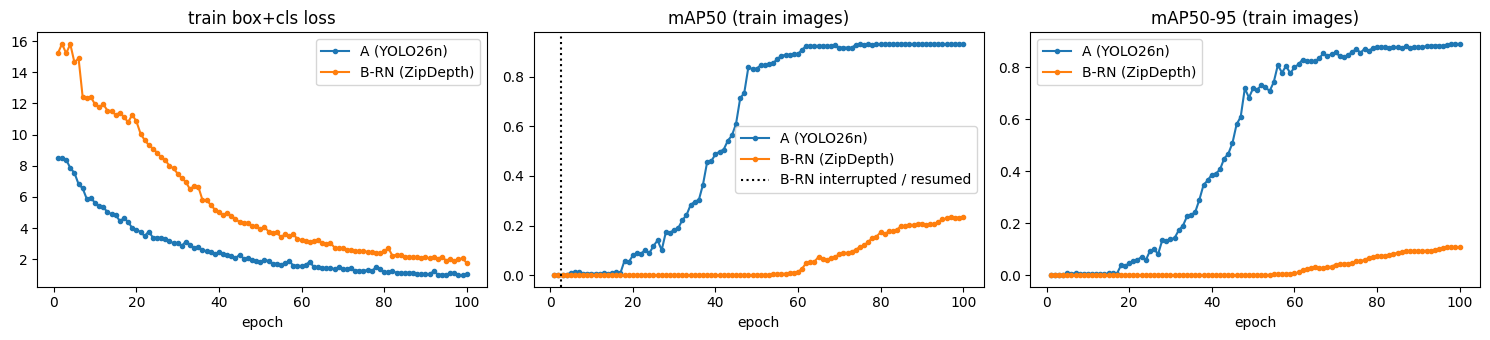

,check,passed
0,1. P3/P4/P5 shapes @640x640,True
1,2. detection output @640x640,True
2,1. P3/P4/P5 shapes @224x640,True
3,2. detection output @224x640,True
4,3. encoder tensors == checkpoint (232),True
5,4. encoder output == ZipDepth (max |diff| 0.0e...,True
6,5. neck/head not loaded from COCO (0/62 conv w...,True
7,"5b. adapters: [1, 1, 1] conv layers, 136,192 p...",True
8,"6. gradient flow (encoder 100%, adapters 100%,...",True
9,6b. training step with batch size 1,True


In [ ]:
if not SKIP_OVERFIT:
    ra = pd.read_csv(CHECK_DIR / "A_overfit/results.csv"); rn = pd.read_csv(CHECK_DIR / "N_overfit/results.csv")
    ra.columns = [c.strip() for c in ra.columns]; rn.columns = [c.strip() for c in rn.columns]

    fig, ax = plt.subplots(1, 3, figsize=(15, 3.5))
    for r, lbl in [(ra, "A (YOLO26n)"), (rn, f"{NEW} (ZipDepth)")]:
        ax[0].plot(r.epoch, r["train/box_loss"] + r["train/cls_loss"], ".-", label=lbl)
        ax[1].plot(r.epoch, r["metrics/mAP50(B)"], ".-", label=lbl)
        ax[2].plot(r.epoch, r["metrics/mAP50-95(B)"], ".-", label=lbl)
    ax[1].axvline(INTERRUPT_AT + 0.5, color="k", ls=":", label=f"{NEW} interrupted / resumed")
    for a, t in zip(ax, ["train box+cls loss", "mAP50 (train images)", "mAP50-95 (train images)"]):
        a.set_title(t); a.set_xlabel("epoch"); a.legend()
    plt.tight_layout(); plt.show()

    best_n = YOLO(str(CHECK_DIR / "N_overfit/weights/best.pt"))            # reload from disk
    det = best_n.predict(TINY[0], imgsz=OVERFIT["imgsz"], verbose=False)[0]
    final = {k: r["metrics/mAP50(B)"].iloc[-1] for k, r in (("A", ra), (NEW, rn))}
    checks["7. resumed run completed all epochs"] = list(rn.epoch) == list(range(1, OVERFIT["epochs"] + 1))
    checks["7. best.pt reloads as ZipDepth model and predicts"] = isinstance(best_n.model.model[0], ZipDepthBackbone) and det.boxes is not None
    drop = {c: 1 - rn[f"train/{c}"].iloc[-1] / rn[f"train/{c}"].iloc[0] for c in ("box_loss", "cls_loss")}
    checks[f"8. {NEW} learns: train loss -{100 * drop['box_loss']:.0f}% box / -{100 * drop['cls_loss']:.0f}% cls, "
           f"mAP50 {final[NEW]:.2f} (A {final['A']:.2f})"] = SMOKE or (min(drop.values()) >= 0.5 and final[NEW] >= 0.1)
check_df = pd.DataFrame({"check": list(checks), "passed": list(checks.values())})
check_df

In [ ]:
assert all(checks.values()), "sanity checks failed - fix before training:\n" + check_df[~check_df.passed].to_string()
run_dir.mkdir(parents=True, exist_ok=True)
CHECKS_FILE.write_text(json.dumps({k: bool(v) for k, v in checks.items()}, indent=1))   # reused after a disconnect
print("all checks passed")

all checks passed


## 6. Training

Same logic as Runs A and B: skipped if `runs/B_zipdepth_rn/weights/last.pt` is finished, resumed if unfinished, otherwise
trained with the locked configuration (plus `SCHEDULE`, if set) via `ZipDepthTrainer`. The callback logs time, peak GPU
memory and effective batch per epoch.

In [ ]:
def add_logging_callbacks(model):
    state = {}
    def start(tr):
        state["t0"] = time.time()
        if torch.cuda.is_available():
            torch.cuda.reset_peak_memory_stats()
    def end(tr):
        cuda = torch.cuda.is_available()
        row = dict(epoch=tr.epoch + 1, train_seconds=time.time() - state["t0"], batch=tr.batch_size,
                   peak_alloc_mib=torch.cuda.max_memory_allocated() / 2**20 if cuda else 0.0,
                   peak_reserved_mib=torch.cuda.max_memory_reserved() / 2**20 if cuda else 0.0)
        pd.DataFrame([row]).to_csv(epoch_log, mode="a", header=not epoch_log.exists(), index=False)
    model.add_callback("on_train_epoch_start", start)
    model.add_callback("on_train_epoch_end", end)
    return model

ZipDepthTrainer.zipdepth_ckpt = str(ZD_CKPT)
ZipDepthTrainer.adapter_layers, ZipDepthTrainer.coco_neck_head = ADAPTER_LAYERS, COCO_NECK_HEAD
finished = last_pt.exists() and torch.load(last_pt, map_location="cpu", weights_only=False).get("epoch", -1) == -1
if finished:
    print(f"finished run found, training skipped: {run_dir}")
elif last_pt.exists():
    add_logging_callbacks(YOLO(str(last_pt))).train(trainer=ZipDepthTrainer, resume=True)
else:
    args = {**TRAIN_CFG, "project": str(RUNS), "name": RUN_N, "exist_ok": True, "device": DEVICE}
    add_logging_callbacks(YOLO("yolo26n.yaml")).train(trainer=ZipDepthTrainer, **args)
assert best_pt.exists()

Ultralytics 8.4.171 🚀 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=ram, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/datasets/kitti.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.yaml, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=B_zipdepth_rn, nbs=64, nms=None, opset=None, optimize=False, 

/usr/local/lib/python3.13/dist-packages/torch/autograd/graph.py:869: UserWarning: adaptive_avg_pool2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


       1/50       2.9G      3.152      4.447    0.01401          9        640: 100% ━━━━━━━━━━━━ 375/375 3.5it/s 1:48
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 47/47 4.8it/s 9.8s
                   all       1496       8128      0.779     0.0272     0.0152    0.00448

      Epoch    GPU_mem   box_loss   cls_loss    l1_loss  Instances       Size
       2/50       2.9G      2.735      3.347    0.01057        153        640: 0% ──────────── 0/375  0.3s

/usr/local/lib/python3.13/dist-packages/torch/autograd/graph.py:869: UserWarning: adaptive_avg_pool2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


       2/50      2.91G      2.535      3.086   0.009673          2        640: 100% ━━━━━━━━━━━━ 375/375 3.6it/s 1:44
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 47/47 6.4it/s 7.3s
                   all       1496       8128      0.606       0.09     0.0832     0.0306

      Epoch    GPU_mem   box_loss   cls_loss    l1_loss  Instances       Size
       3/50      2.91G      2.458      2.769   0.008244        226        640: 0% ──────────── 0/375  0.3s

...

      48/50      2.96G      1.198      0.821   0.003693          6        640: 100% ━━━━━━━━━━━━ 375/375 3.7it/s 1:42
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 47/47 5.4it/s 8.6s
                   all       1496       8128      0.837      0.625      0.736       0.46

      Epoch    GPU_mem   box_loss   cls_loss    l1_loss  Instances       Size
      49/50      2.96G      1.201     0.8105   0.003801         64        640: 0% ──────────── 0/375  0.2s

/usr/local/lib/python3.13/dist-packages/torch/autograd/graph.py:869: UserWarning: adaptive_avg_pool2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


      49/50      2.96G      1.189     0.8103   0.003628          6        640: 100% ━━━━━━━━━━━━ 375/375 3.6it/s 1:44
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 47/47 6.1it/s 7.7s
                   all       1496       8128      0.805      0.636      0.733      0.458

      Epoch    GPU_mem   box_loss   cls_loss    l1_loss  Instances       Size
      50/50      2.96G      1.243     0.8512   0.004129         79        640: 0% ──────────── 0/375  0.3s

/usr/local/lib/python3.13/dist-packages/torch/autograd/graph.py:869: UserWarning: adaptive_avg_pool2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


      50/50      2.96G      1.183     0.8039    0.00364          5        640: 100% ━━━━━━━━━━━━ 375/375 3.6it/s 1:43
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 47/47 5.4it/s 8.7s
                   all       1496       8128      0.836      0.628      0.733       0.46

50 epochs completed in 1.569 hours.
Optimizer stripped from /content/drive/MyDrive/lab/runs/B_zipdepth_rn/weights/last.pt, 16.2MB
Optimizer stripped from /content/drive/MyDrive/lab/runs/B_zipdepth_rn/weights/best.pt, 16.2MB

Validating /content/drive/MyDrive/lab/runs/B_zipdepth_rn/weights/best.pt...
Ultralytics 8.4.171 🚀 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
YOLO26n summary (fused): 199 layers, 7,785,549 parameters, 0 gradients, 19.5 GFLOPs
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 47/47 4.0it/s 11.8s
                   all       1496       8128      0.836      0.628  

## 7. Training curves (A, B, B-RN)

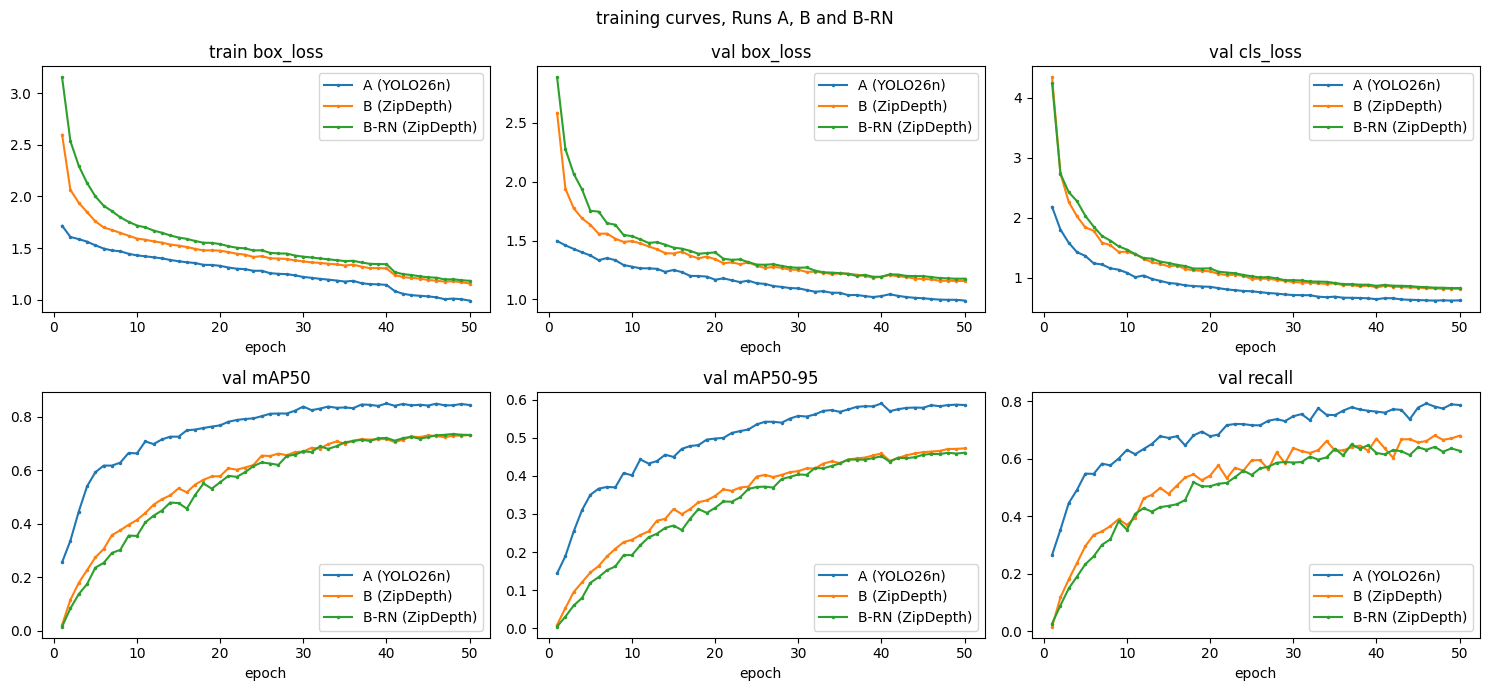

,Run A,Run B,Run B-RN
epochs,50,50,50
best epoch,40,50,50
best mAP50-95,0.5896,0.4719,0.4605
last mAP50-95,0.5855,0.4719,0.4605
"mAP50-95 slope, last 5 ep",0.000486,0.002235,0.000751
val box_loss min epoch,50,49,49
train s/epoch,103.8,104.5,104.3
peak train mem alloc (MiB),2423,2829,2827
batch (effective),16,16,16


In [ ]:
def read_run(name):
    d = RUNS / name
    r = pd.read_csv(d / "results.csv"); r.columns = [c.strip() for c in r.columns]
    e = pd.read_csv(d / "epoch_log.csv").drop_duplicates("epoch", keep="last") if (d / "epoch_log.csv").exists() else None
    return r, e

RUN_OF = {"A": RUN_A, "B": RUN_B, NEW: RUN_N}
logs = {k: read_run(RUN_OF[k]) for k in KEYS}
LABEL = {"A": "A (YOLO26n)", "B": "B (ZipDepth)", NEW: f"{NEW} (ZipDepth)"}

fig, ax = plt.subplots(2, 3, figsize=(15, 7))
panels = [("train/box_loss", "train box_loss"), ("val/box_loss", "val box_loss"), ("val/cls_loss", "val cls_loss"),
          ("metrics/mAP50(B)", "val mAP50"), ("metrics/mAP50-95(B)", "val mAP50-95"), ("metrics/recall(B)", "val recall")]
for a, (col, title) in zip(ax.flat, panels):
    for k in KEYS:
        r = logs[k][0]
        a.plot(r.epoch, r[col], ".-", ms=3, label=LABEL[k])
    a.set_title(title); a.set_xlabel("epoch"); a.legend()
fig.suptitle(f"training curves, Runs A, B and {NEW}"); plt.tight_layout(); plt.show()

def curve_summary(r, e):
    m = r["metrics/mAP50-95(B)"].values; k = min(5, len(m) - 1)
    return {"epochs": len(r), "best epoch": int(r.epoch[m.argmax()]), "best mAP50-95": m.max(), "last mAP50-95": m[-1],
            f"mAP50-95 slope, last {k} ep": np.polyfit(np.arange(k), m[-k:], 1)[0] if k >= 2 else np.nan,
            "val box_loss min epoch": int(r.epoch[r["val/box_loss"].values.argmin()]),
            "train s/epoch": e.train_seconds.mean() if e is not None else np.nan,
            "peak train mem alloc (MiB)": e.peak_alloc_mib.max() if e is not None else np.nan,
            "batch (effective)": int(e.batch.iloc[-1]) if e is not None else np.nan}
curves = pd.DataFrame({f"Run {k}": curve_summary(*logs[k]) for k in KEYS})
curves.style.format("{:.4g}")

## 8. Evaluation

The three `best.pt` files are evaluated here with identical code: Ultralytics validation (per-class AP) and the
size-bucket AP of `lab_eval`. Δ = B-RN − B (effect of this run's change) and B-RN − A (gap to the baseline).

In [13]:
MODELS = {"A": YOLO(str(RUNS / RUN_A / "weights/best.pt")), "B": YOLO(str(RUNS / RUN_B / "weights/best.pt")),
          NEW: YOLO(str(best_pt))}
n_gt = val.groupby("cls").size()
per_class, overall, val_speed = {}, {}, {}
for k, mdl in MODELS.items():
    mt = mdl.val(data=str(RUN_DATA), imgsz=EXP["imgsz"], batch=EXP["batch"], device=DEVICE, plots=True,
                 project=str(RUNS / RUN_OF[k]), name="val_best", exist_ok=True, verbose=False)
    per_class[k] = pd.DataFrame([dict(cls=NAMES[int(c)], **dict(zip(["P", "R", "AP50", "AP50-95"], mt.box.class_result(i))))
                                 for i, c in enumerate(mt.box.ap_class_index)]).set_index("cls")
    overall[k] = dict(mAP50=float(mt.box.map50), mAP50_95=float(mt.box.map), P=float(mt.box.mp), R=float(mt.box.mr))
    val_speed[k] = mt.speed

cmp_cls = pd.DataFrame({"n_gt": n_gt.rename(index=NAMES)})
for met in ["AP50-95", "AP50", "R"]:
    for k in KEYS:
        cmp_cls[f"{met} {k}"] = per_class[k][met]
    cmp_cls[f"{met} Δ vs B"] = cmp_cls[f"{met} {NEW}"] - cmp_cls[f"{met} B"]
    cmp_cls[f"{met} Δ vs A"] = cmp_cls[f"{met} {NEW}"] - cmp_cls[f"{met} A"]
ov_key = {"AP50-95": "mAP50_95", "AP50": "mAP50", "R": "R"}
all_row = {"n_gt": len(val)}
for met, ok in ov_key.items():
    all_row.update({f"{met} {k}": overall[k][ok] for k in KEYS})
    all_row[f"{met} Δ vs B"] = overall[NEW][ok] - overall["B"][ok]
    all_row[f"{met} Δ vs A"] = overall[NEW][ok] - overall["A"][ok]
cmp_cls.loc["all"] = pd.Series(all_row)
cmp_cls["n_gt"] = cmp_cls["n_gt"].astype(int)
cmp_cls.round(3).style.background_gradient(subset=[c for c in cmp_cls if "Δ" in c], cmap="RdYlGn", vmin=-0.1, vmax=0.1).format(precision=3)

Ultralytics 8.4.171 🚀 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
YOLO26n summary (fused): 120 layers, 2,376,396 parameters, 0 gradients, 5.3 GFLOPs
WARNING ⚠️ val: Slow image access detected (ping: 0.0±0.0 ms, read: 23.4±8.8 MB/s, size: 48.0 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips
val: Scanning /content/datasets/kitti/labels/val.cache... 1496 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1496/1496 313.7Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 94/94 6.8it/s 13.9s
                   all       1496       8128      0.864      0.762      0.849      0.588
Speed: 0.5ms preprocess, 2.3ms inference, 0.0ms loss, 1.4ms postprocess per image
Results saved to /content/drive/MyDrive/lab/runs/A_yolo26n/val_best
Ultralytics 8.4.171 🚀 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
YOLO26

,n_gt,AP50-95 A,AP50-95 B,AP50-95 B-RN,AP50-95 Δ vs B,AP50-95 Δ vs A,AP50 A,AP50 B,AP50 B-RN,AP50 Δ vs B,AP50 Δ vs A,R A,R B,R B-RN,R Δ vs B,R Δ vs A
cls,,,,,,,,,,,,,,,,
car,5716,0.752,0.702,0.695,-0.007,-0.057,0.955,0.933,0.927,-0.006,-0.028,0.893,0.870,0.844,-0.026,-0.049
van,555,0.692,0.593,0.574,-0.018,-0.118,0.914,0.838,0.802,-0.036,-0.112,0.836,0.771,0.701,-0.070,-0.135
truck,223,0.767,0.686,0.672,-0.014,-0.096,0.959,0.900,0.888,-0.012,-0.071,0.893,0.843,0.803,-0.040,-0.090
pedestrian,921,0.398,0.291,0.290,-0.001,-0.107,0.728,0.607,0.610,0.002,-0.118,0.604,0.522,0.488,-0.035,-0.116
Person_sitting,36,0.349,0.228,0.206,-0.023,-0.143,0.674,0.451,0.493,0.042,-0.181,0.611,0.444,0.444,0.000,-0.167
cyclist,352,0.473,0.315,0.322,0.007,-0.150,0.781,0.622,0.634,0.012,-0.147,0.685,0.562,0.488,-0.075,-0.197
tram,117,0.690,0.530,0.544,0.014,-0.146,0.937,0.817,0.883,0.066,-0.055,0.884,0.838,0.795,-0.043,-0.089
misc,208,0.583,0.430,0.382,-0.048,-0.201,0.841,0.680,0.621,-0.059,-0.221,0.690,0.577,0.452,-0.125,-0.238
all,8128,0.588,0.472,0.461,-0.011,-0.127,0.849,0.731,0.732,0.001,-0.116,0.762,0.679,0.627,-0.052,-0.135


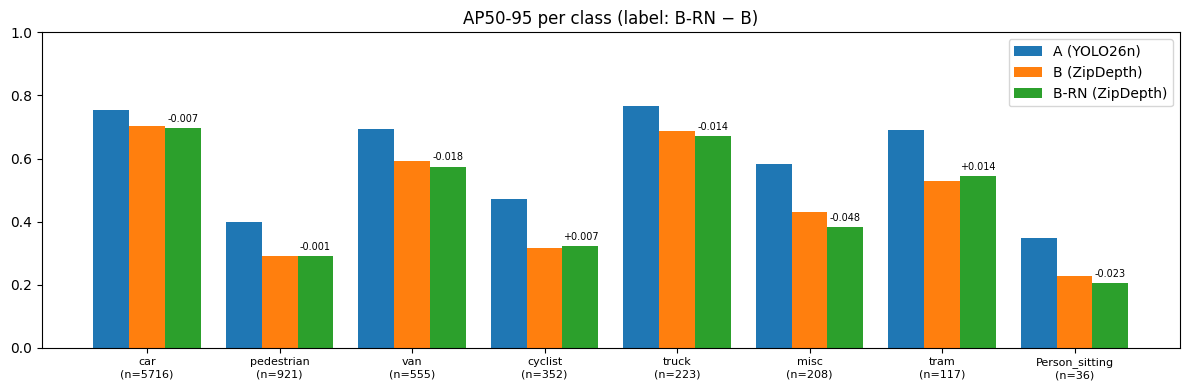

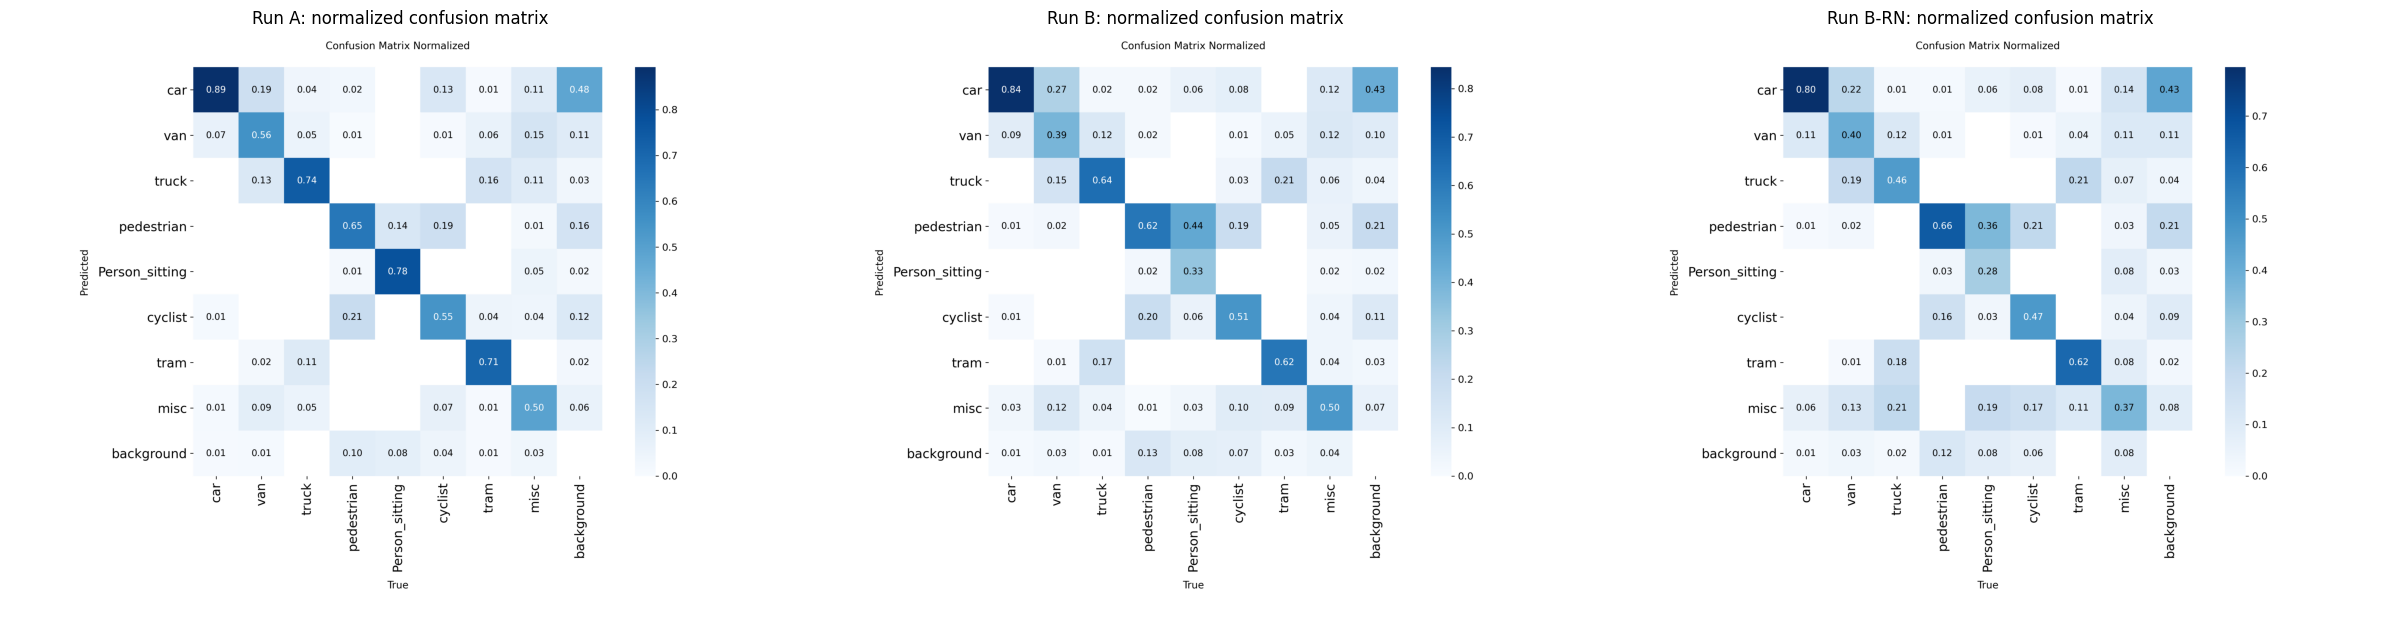

In [14]:
pc = cmp_cls.drop("all").sort_values("n_gt", ascending=False); x = np.arange(len(pc)); w = 0.27
fig, ax = plt.subplots(figsize=(12, 4))
for j, k in enumerate(KEYS):
    ax.bar(x + (j - 1) * w, pc[f"AP50-95 {k}"], w, label=LABEL[k])
for i, d in enumerate(pc["AP50-95 Δ vs B"]):
    ax.text(i + w, pc[f"AP50-95 {NEW}"].iloc[i] + .02, f"{d:+.3f}", ha="center", fontsize=7)
ax.set_xticks(x, [f"{c}\n(n={n})" for c, n in zip(pc.index, pc.n_gt)], fontsize=8); ax.set_ylim(0, 1)
ax.set_title(f"AP50-95 per class (label: {NEW} − B)"); ax.legend(); plt.tight_layout(); plt.show()

fig, ax = plt.subplots(1, 3, figsize=(24, 6.8))
for a, k in zip(ax, KEYS):
    a.imshow(plt.imread(RUNS / RUN_OF[k] / "val_best/confusion_matrix_normalized.png")); a.axis("off")
    a.set_title(f"Run {k}: normalized confusion matrix")
plt.tight_layout(); plt.show()

## 9. AP by object size

Primary small-object metric: `car` AP50-95 in the small bucket (800 objects; the other classes have ≤ 37 small
objects). Δ = B-RN − B.

In [15]:
size = {k: size_table(collect_predictions(mdl, val, imgsz=EXP["imgsz"], device=DEVICE), NAMES) for k, mdl in MODELS.items()}
cols = ["mAP50", "mAP50-95", "car", "van", "pedestrian", "cyclist"]
cmp_size = pd.concat({k: size[k][cols] for k in KEYS}, axis=1)
for c in cols:
    cmp_size[(f"Δ {NEW} − B", c)] = cmp_size[(NEW, c)] - cmp_size[("B", c)]
cmp_size.insert(0, ("", "n_gt"), size["A"]["n_gt"])
cmp_size.round(3)

A                                            \
                  n_gt  mAP50 mAP50-95    car    van pedestrian cyclist   
bucket                                                                    
all               8128  0.842    0.584  0.750  0.685      0.398   0.481   
small (<25px)      889  0.530    0.306  0.550  0.371      0.024   0.195   
medium (25-50px)  2903  0.695    0.455  0.706  0.591      0.119   0.390   
large (>=50px)    4336  0.881    0.646  0.832  0.794      0.446   0.550   

                      B                  ...   B-RN                            \
                  mAP50 mAP50-95    car  ...    car    van pedestrian cyclist   
bucket                                   ...                                    
all               0.733    0.473  0.701  ...  0.691  0.574      0.288   0.314   
small (<25px)     0.427    0.218  0.470  ...  0.471  0.247      0.017   0.079   
medium (25-50px)  0.599    0.376  0.657  ...  0.643  0.494      0.083   0.253   
large (>=50px)    0.781    0.530  0.792  ...  0.782  0.684      0.324   0.366   

                 Δ B-RN − B                                            
                      mAP50 mAP50-95    car    van pedestrian cyclist  
bucket                                                                 
all                  -0.009   -0.016 -0.010 -0.010      0.002  -0.016  
small (<25px)         0.008    0.023  0.001 -0.051      0.016   0.062  
medium (25-50px)      0.002   -0.001 -0.014  0.009     -0.004   0.071  
large (>=50px)       -0.011   -0.023 -0.010 -0.017      0.003  -0.061  

[4 rows x 25 columns]

In [ ]:
buckets = list(SIZE_BUCKETS); x = np.arange(len(buckets)); w = 0.27
fig, ax = plt.subplots(1, 3, figsize=(16, 3.8))
for a, c, t in zip(ax, ["mAP50-95", "car", "pedestrian"], ["mAP50-95 (all classes)", "car AP50-95 (primary: small)", "pedestrian AP50-95"]):
    for j, k in enumerate(KEYS):
        a.bar(x + (j - 1) * w, size[k].loc[buckets, c], w, label=k)
    for i, b in enumerate(buckets):
        d = size[NEW].loc[b, c] - size["B"].loc[b, c]
        a.text(i + w, size[NEW].loc[b, c] + .02, f"{d:+.3f}", ha="center", fontsize=7)
    a.set_xticks(x, [b.split(" ")[0] for b in buckets]); a.set_ylim(0, 1); a.set_title(t); a.legend()
fig.suptitle(f"AP50-95 by object size (label: {NEW} − B)"); plt.tight_layout(); plt.show()

## 10. Feature maps

PCA-RGB (top-3 components, variance explained in the title) of the tensors each model hands to the neck (layers
4 / 6 / 10) and of the neck outputs fed to the head (layers 16 / 19 / 22), on the val image with the most small
objects (same image as in the Run A and Run B notebooks), resized to 192×640. Rows: A, B, B-RN.

In [ ]:
LAYERS = {"P3 in (L4)": 4, "P4 in (L6)": 6, "P5 in (L10)": 10, "P3 out (L16)": 16, "P4 out (L19)": 19, "P5 out (L22)": 22}
n_small = val[val.bucket == SMALL].groupby("path").size().sort_values(ascending=False)
feat_img = n_small.index[0]
rgb = np.array(Image.open(feat_img).convert("RGB").resize((640, 192), Image.BILINEAR))
x = torch.from_numpy(rgb).permute(2, 0, 1)[None].float().div(255).to(DEVICE)

def features(mdl):
    # Forward hooks on the listed layers; returns {name: (C, H, W) tensor}
    net = copy.deepcopy(mdl.model).float().eval().to(DEVICE); feats = {}
    hooks = [net.model[i].register_forward_hook(lambda m, a, o, k=k: feats.__setitem__(k, o[0].detach().float().cpu()))
             for k, i in LAYERS.items()]
    with torch.no_grad():
        net(x)
    for h in hooks:
        h.remove()
    return feats

feats = {k: features(m) for k, m in MODELS.items()}
IN, OUT = list(LAYERS)[:3], list(LAYERS)[3:]
rows = [(k, IN) for k in KEYS] + [(k, OUT) for k in KEYS]
fig = plt.figure(figsize=(16, 15.5)); gs = fig.add_gridspec(1 + len(rows), 3, height_ratios=[1.1] + [1] * len(rows))
a = fig.add_subplot(gs[0, :]); a.imshow(rgb); a.axis("off"); a.set_title(f"input {Path(feat_img).name} (192×640)")
pca_var = {k: {} for k in KEYS}
for r, (k, names_) in enumerate(rows):
    for c, n in enumerate(names_):
        img, var = pca_rgb(feats[k][n]); pca_var[k][n] = var
        ax = fig.add_subplot(gs[1 + r, c]); ax.imshow(img, interpolation="nearest"); ax.axis("off")
        ax.set_title(f"{k}: {n} {tuple(feats[k][n].shape)} PC1-3 {100 * var:.0f}%", fontsize=9)
plt.tight_layout(); plt.show()
pd.DataFrame(pca_var).mul(100).round(0).rename_axis("PC1-3 variance (%)")

## 11. Model cost

All three models measured back to back in this session. Fused models: Ultralytics Conv/BN fusion for all, plus RepVGG
fusion of the ZipDepth encoder for B and the new run. Latency = network forward only (no pre-processing, no NMS),
30 warm-up + 200 timed runs; throughput at batch 32 FP16. Training cost comes from each run's `epoch_log.csv`.

In [18]:
from ultralytics.utils.torch_utils import get_flops

fused = {"A": copy.deepcopy(MODELS["A"].model).float().eval().fuse(verbose=False)}
fused.update({k: fuse_zipdepth_yolo(copy.deepcopy(MODELS[k].model).float().eval()) for k in ("B", NEW)})
cost = pd.DataFrame({k: {"params (unfused)": count_params(MODELS[k].model), "params (fused)": count_params(fused[k]),
                         "GFLOPs @640 (fused)": get_flops(fused[k], EXP["imgsz"])} for k in KEYS})

gpu = DEVICE != "cpu"
cfgs = [(1, 640, 640, False), (1, 640, 640, True), (1, 224, 640, False), (1, 224, 640, True), (32 if gpu else 4, 640, 640, gpu)]
if not gpu:
    cfgs = [c for c in cfgs if not c[3]] + [(4, 640, 640, False)]
lat = []
for k in KEYS:
    for b, h, w, half in dict.fromkeys(cfgs):
        L = measure_latency(fused[k], (b, 3, h, w), DEVICE, half=half, warmup=30 if gpu else 2, iters=(200 if b == 1 else 50) if gpu else 5)
        M = peak_inference_memory(fused[k], (b, 3, h, w), DEVICE, half=half)
        lat.append(dict(run=k, batch=b, input=f"{h}x{w}", precision="FP16" if half else "FP32", median_ms=L["median"],
                        img_per_s=b * 1000 / L["median"], peak_mem_mib=M["total_mib"]))
lat_df = pd.DataFrame(lat).pivot_table(index=["batch", "input", "precision"], columns="run",
                                       values=["median_ms", "img_per_s", "peak_mem_mib"], dropna=False)
lat_df = lat_df[lat_df[("median_ms", "A")].notna()]
lat_df = lat_df.reindex(columns=pd.MultiIndex.from_product([["median_ms", "img_per_s", "peak_mem_mib"], KEYS]))
cost.loc["train s/epoch"] = [curves.loc["train s/epoch", f"Run {k}"] for k in KEYS]
cost.loc["peak train mem alloc (MiB)"] = [curves.loc["peak train mem alloc (MiB)", f"Run {k}"] for k in KEYS]
cost[f"{NEW} / B"] = cost[NEW] / cost["B"]
print(f"device: {GPU_NAME}")
display(cost.style.format("{:,.2f}"))
lat_df.round(2)

device: Tesla T4


,A,B,B-RN,B-RN / B
params (unfused),"2,506,920.00","7,911,889.00","7,911,889.00",1.00
params (fused),"2,376,396.00","7,141,005.00","7,141,005.00",1.00
GFLOPs @640 (fused),5.32,17.82,17.82,1.00
train s/epoch,103.84,104.46,104.31,1.00
peak train mem alloc (MiB),"2,423.19","2,829.40","2,826.74",1.00


median_ms                 img_per_s                  \
                                A       B    B-RN         A       B    B-RN   
batch input   precision                                                       
1     224x640 FP16          15.27   10.84   14.51     65.47   92.27   68.93   
              FP32           9.48    8.90    9.30    105.50  112.33  107.54   
      640x640 FP16          11.40   13.95   10.81     87.73   71.68   92.48   
              FP32           9.47   13.30   13.26    105.58   75.16   75.42   
32    640x640 FP16          85.28  131.13  121.54    375.24  244.03  263.29   

                        peak_mem_mib                  
                                   A       B    B-RN  
batch input   precision                               
1     224x640 FP16            237.55  262.21  288.33  
              FP32            248.92  282.07  310.94  
      640x640 FP16            246.15  273.99  301.34  
              FP32            263.15  305.68  333.52  
32    640x640 FP16            610.28  929.83  957.62

## 12. Qualitative results

Same four val images as the Run A and Run B notebooks. Rows per image: ground truth (red = small), Run A, Run B and the
new run (confidence ≥ 0.25).

In [ ]:
qfile = ROOT / "results" / ("qualitative_images_smoke.txt" if SMOKE else "qualitative_images.txt")
SHOW = [str(KITTI_DIR / "images/val" / n) for n in qfile.read_text().split()] if qfile.exists() else []
SHOW = [p for p in SHOW if p in set(val.path)] or list(n_small.index[:4])

colors = plt.cm.tab10(np.arange(len(NAMES)))
R = 1 + len(KEYS)                                       # rows per image: GT + one per model
fig, axes = plt.subplots(R * ((len(SHOW) + 1) // 2), 2, figsize=(16, 2.5 * R * ((len(SHOW) + 1) // 2)))
for j, p in enumerate(SHOW):
    img = np.asarray(Image.open(p).convert("RGB")); g = val[val.path == p]
    rows = axes[(j // 2) * R:(j // 2) * R + R, j % 2]
    for a in rows:
        a.imshow(img); a.axis("off")
    for _, b in g.iterrows():
        rows[0].add_patch(plt.Rectangle((b.x1, b.y1), b.x2 - b.x1, b.y2 - b.y1, fill=False, lw=1.2,
                                        ec="red" if b.bucket == SMALL else "lime"))
    rows[0].set_title(f"{Path(p).name} ground truth: {len(g)} objects, {(g.bucket == SMALL).sum()} small", fontsize=9)
    for a, k in zip(rows[1:], KEYS):
        r = MODELS[k].predict(p, imgsz=EXP["imgsz"], conf=0.25, device=DEVICE, verbose=False)[0]
        for c, s, (x1, y1, x2, y2) in zip(r.boxes.cls.int().tolist(), r.boxes.conf.tolist(), r.boxes.xyxy.tolist()):
            a.add_patch(plt.Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, ec=colors[c], lw=1.2))
            a.text(x1, y1 - 2, f"{NAMES[c]} {s:.2f}", color=colors[c], fontsize=6)
        a.set_title(f"Run {k}: {len(r.boxes)} detections", fontsize=9)
plt.tight_layout(); plt.show()

## 13. Comparison and export

Final table for A, B and B-RN (accuracy, parameters, speed, GPU memory), with the effect of this run's change
(B-RN − B) and the remaining gap to the baseline (B-RN − A). Saved to `results/comparison_B_zipdepth_rn.csv`; all numbers of
this run (and the same-session A and B numbers) go to `results/results_B_zipdepth_rn.json`.

In [20]:
b1 = lambda k, prec: lat_df.loc[(1, "640x640", prec), ("median_ms", k)]
bt = lat_df.index[-1]
row = lambda k: {
    "mAP50": overall[k]["mAP50"], "mAP50-95": overall[k]["mAP50_95"],
    "AP50-95 car": per_class[k].loc["car", "AP50-95"], "AP50-95 pedestrian": per_class[k].loc["pedestrian", "AP50-95"],
    "AP50-95 cyclist": per_class[k].loc["cyclist", "AP50-95"],
    "mAP50-95 small": size[k].loc[SMALL, "mAP50-95"], "AP50-95 car small (primary)": size[k].loc[SMALL, "car"],
    "params fused (M)": cost.loc["params (fused)", k] / 1e6, "GFLOPs @640": cost.loc["GFLOPs @640 (fused)", k],
    f"latency b1 640 {bt[2]} (ms)": b1(k, bt[2]), f"throughput b{bt[0]} {bt[2]} (img/s)": lat_df.loc[bt, ("img_per_s", k)],
    "peak inference mem b1 (MiB)": lat_df.loc[(1, "640x640", bt[2]), ("peak_mem_mib", k)],
    "peak train mem (MiB)": cost.loc["peak train mem alloc (MiB)", k], "train s/epoch": cost.loc["train s/epoch", k],
    "epochs (best)": f'{int(curves.loc["epochs", f"Run {k}"])} ({int(curves.loc["best epoch", f"Run {k}"])})',
}
comparison = pd.DataFrame({k: row(k) for k in KEYS})
num = comparison.drop("epochs (best)")
comparison[f"Δ ({NEW} − B)"] = pd.concat([num[NEW] - num["B"], pd.Series({"epochs (best)": ""})])
comparison[f"Δ ({NEW} − A)"] = pd.concat([num[NEW] - num["A"], pd.Series({"epochs (best)": ""})])
(ROOT / "results").mkdir(exist_ok=True)
comparison.to_csv(ROOT / "results" / f"comparison_{RUN_N}.csv")

results_N = dict(
    run=NEW, name=RUN_N, smoke=SMOKE, gpu=GPU_NAME, torch=torch.__version__, ultralytics=ultralytics.__version__,
    backbone="ZipDepth-base encoder (depth-pretrained)", adapter_layers=ADAPTER_LAYERS,
    neck_head_init="COCO" if COCO_NECK_HEAD else "random", config=TRAIN_CFG,
    sanity_checks={k: bool(v) for k, v in checks.items()},
    training={k: (v.item() if hasattr(v, "item") else v) for k, v in curves[f"Run {NEW}"].items()},
    overall=overall[NEW], per_class=per_class[NEW].reset_index().to_dict("records"),
    by_size=size[NEW].reset_index().to_dict("records"), car_small_ap50_95=float(size[NEW].loc[SMALL, "car"]),
    params=dict(unfused=int(cost.loc["params (unfused)", NEW]), fused=int(cost.loc["params (fused)", NEW]),
                by_part=params_init[f"Run {NEW}"].to_dict()),
    gflops_640=float(cost.loc["GFLOPs @640 (fused)", NEW]),
    latency=pd.DataFrame(lat).to_dict("records"), pca_var_top3=pca_var, val_speed_ms=val_speed,
    same_session={k: dict(overall=overall[k], by_size=size[k].reset_index().to_dict("records")) for k in ("A", "B")},
)
save_json(results_N, ROOT / "results" / f"results_{RUN_N}.json")
comparison

,A,B,B-RN,Δ (B-RN − B),Δ (B-RN − A)
mAP50,0.849,0.731,0.732,0.001,-0.116
mAP50-95,0.588,0.472,0.461,-0.011,-0.127
AP50-95 car,0.752,0.702,0.695,-0.007,-0.057
AP50-95 pedestrian,0.398,0.291,0.29,-0.001,-0.107
AP50-95 cyclist,0.473,0.315,0.322,0.007,-0.15
mAP50-95 small,0.306,0.218,0.241,0.023,-0.065
AP50-95 car small (primary),0.55,0.47,0.471,0.001,-0.079
params fused (M),2.376,7.141,7.141,0.0,4.765
GFLOPs @640,5.317,17.825,17.825,0.0,12.507
latency b1 640 FP16 (ms),11.398,13.951,10.813,-3.138,-0.585
